# Scikit-Learn

## Setup e importazioni

Iniziamo importando le librerie essenziali che useremo durante tutto il corso.

In [1]:
# Librerie fondamentali
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Caricare un dataset di esempio (dataset integrati)

Scikit-learn include diversi dataset di esempio. Il più famoso è **Iris**: 150 fiori di 3 specie diverse, descritti da 4 misurazioni.

Il primo passo è importare la funzione di caricamento del dataset. A [questo](https://scikit-learn.org/stable/datasets/toy_dataset.html) link sono presenti i diversi dataset integrati disponibili in scikit-learn.

In [2]:
from sklearn.datasets import load_iris

Successivamente è possibile caricare il dataset e cominciare ad esplorarne la struttura

In [3]:
# Caricare il dataset Iris
iris = load_iris()

# Esplorare la struttura
print("Tipo dell'oggetto:", type(iris))
print("\nChiavi disponibili:", iris.keys())

Tipo dell'oggetto: <class 'sklearn.utils._bunch.Bunch'>

Chiavi disponibili: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


Il dataset è caricato sotto forma di dizionario con diverse chiavi. Le più importanti sono:
- data - La matrice delle features. È l'input X per il modello.
- target - Il vettore delle etichette. È l'output y che vogliamo predire.
- feature_names - I nomi delle colonne di data (in altri termini i nomi delle colonne).
- target_names - I nomi delle classi da predire. 
- DESCR - Una stringa di testo con la descrizione completa del dataset: origine, citazioni, significato delle variabili.
- frame - Il dataset come pandas DataFrame (se disponibile).
- filename - Il percorso al file CSV originale sul tuo sistema. Sklearn salva i dataset in una cartella locale.

Guardiamo la descrizione del dataset

In [4]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

#### Notazione del machine learning: X e y
Nel machine learning supervisionato abbiamo sempre due elementi:
X (le features) - Sono le informazioni che usiamo per fare la predizione. Tutto ciò che "osserviamo" o "misuriamo" su ogni campione. Nel caso di Iris: lunghezza e larghezza di sepali e petali.
y (il target) - È quello che vogliamo predire. La "risposta giusta" che conosciamo per i dati di training. Nel caso di Iris: la specie del fiore.

**Convenzione universale in sklearn**:
- X maiuscola per le features, sempre matrice 2D con shape (n_campioni, n_features)
- y minuscola per il target, vettore 1D con shape (n_campioni,)

Tutti i metodi sklearn si aspettano dati in questo formato.



Cominciamo quindi esplorare i dati caricati:
1. per prima cosa estraiamo X ed y
2. controllare le dimensioni e i nomi prima di procedere

In [11]:
X = iris.data
y = iris.target

print("Shape delle features X:", X.shape)
print("Shape del target y:", y.shape)
print("\nNomi delle features:", iris.feature_names)
print("Nomi delle classi:", iris.target_names)

Shape delle features X: (150, 4)
Shape del target y: (150,)

Nomi delle features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Nomi delle classi: ['setosa' 'versicolor' 'virginica']


Possiamo convertire il dataset caricato in un Pandas Dataframe, ai fini di esplorazione e visualizzazione. Pandas offre metodi comodi come .describe(), .value_counts(), .corr() che sklearn non ha.

In [12]:
# Crea un dataframe da X contenente le feature del dataset IRIS e aggiungi una colonna per le specie
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y

# Visualizza le prime righe del dataframe
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


Possiamo anche osservare delle statistiche sul dataset con df.describe() e guardare quanti esempi abbiamo per classe con value_counts()

In [7]:
# Statistiche descrittive delle features
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [8]:
# Visualizza la distribuzione delle classi
df['species'].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

Inoltre, utilizzando la funzione plot di pandas possiamo vedere come si distribuiscono i dati

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

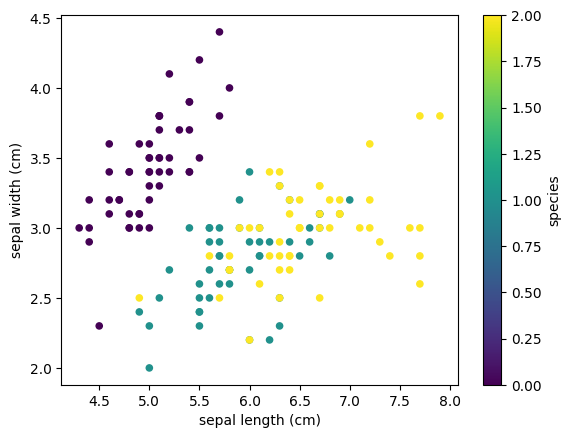

In [13]:
# Visualizza come le diverse specie si distribuiscono in funzione di due features specifiche (sepal length e sepal width)
# c indica la colorazione in base alla specie e colormap specifica la mappa dei colori da usare
df.plot(kind='scatter', x='sepal length (cm)', y='sepal width (cm)', c='species', colormap='viridis')

Possiamo migliorare questo grafico, mostrando una legenda con i nomi delle specie, anziche dei valori numeri. Per farlo usiamo matplotlib

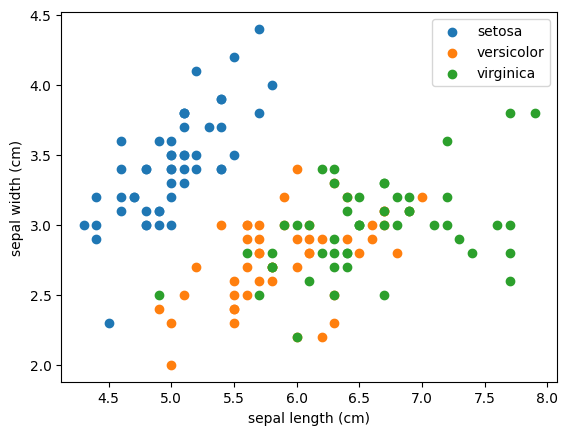

In [21]:
# invece di usare come target un intero, possiamo usare i nomi delle specie
fig, ax = plt.subplots()
for idx, name in enumerate(iris.target_names):
    subset = df[df['species'] == idx]
    ax.scatter(subset['sepal length (cm)'], subset['sepal width (cm)'], label=name)
ax.set_xlabel('sepal length (cm)')
ax.set_ylabel('sepal width (cm)')
ax.legend()
plt.show()

## Esercizio 1

1. Caricare il dataset Wine (suggerimento, guardare documentazione di scikitlearn)
2. Estrarre X ed y
3. Quanti dati abbiamo?
4. Quante e quali features abbiamo?
5. Quante e quali sono le etichette? 
6. Visualizzare tramite un grafico a barre come le classi si distribuiscono
7. Visualizzare la relazione tra due feature tramite uno scatterplot (es. grado alcoolico vs intensità del colore)

### Svolgimento

1. Caricare il dataset Wine (suggerimento, guardare documentazione di scikitlearn)

In [2]:
from sklearn.datasets import load_wine
wine = load_wine()

print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

2. Estrarre X ed y
3. Quanti dati abbiamo?
4. Quante e quali features abbiamo?
5. Quante e quali sono le etichette? 

In [3]:
X_wine = wine.data
y_wine = wine.target

print("Shape delle features X_wine:", X_wine.shape)
print("Shape del target y_wine:", y_wine.shape)
print("\nNomi delle features wine:", wine.feature_names)
print("Nomi delle classi wine:", wine.target_names)

Shape delle features X_wine: (178, 13)
Shape del target y_wine: (178,)

Nomi delle features wine: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Nomi delle classi wine: ['class_0' 'class_1' 'class_2']


6. Visualizzare tramite un grafico a barre come le classi si distribuiscono


<Axes: xlabel='target'>

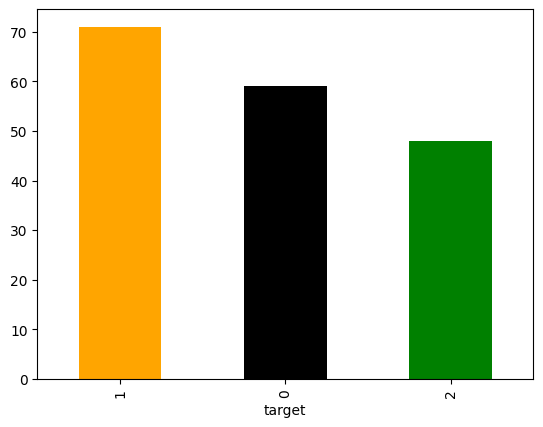

In [54]:
# creo un dataframe per il dataset wine e aggiungo una colonna per il target
df_wine = pd.DataFrame(X_wine, columns=wine.feature_names)
df_wine['target'] = y_wine

# stampo la distribuzione delle classi del dataset wine
df_wine['target'].value_counts().plot(kind='bar', color=['orange','black','g'])

7. Visualizzare la relazione tra due feature tramite uno scatterplot (es. grado alcoolico vs intensità del colore)

<Axes: xlabel='flavanoids', ylabel='proline'>

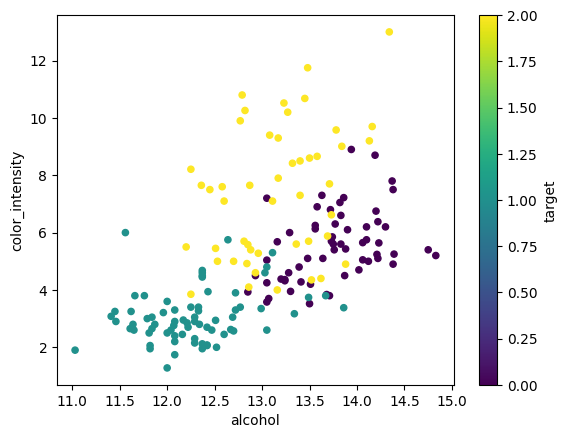

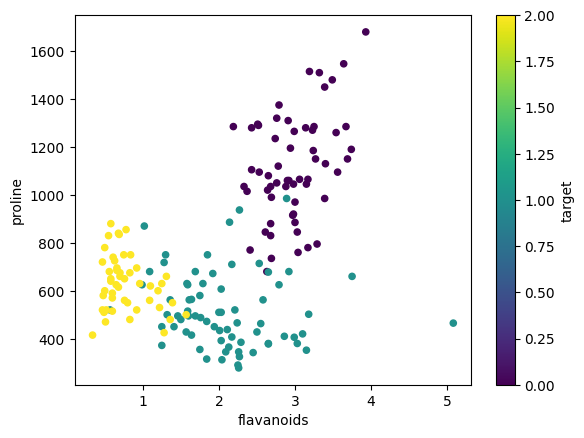

In [55]:
# creo uno scatter per visualizzare la relazione tra alcohol e color_intensity
df_wine.plot(kind='scatter', x='alcohol', y='color_intensity', c='target', colormap='viridis')

# creo uno scatter per visualizzare la relazione tra flavanoids e proline
df_wine.plot(kind='scatter', x='flavanoids', y='proline', c='target', colormap='viridis')


## Extra: caricare un proprio dataset

Possiamo utilizzare pandas per caricare un nostro dataset e successivamente utilizzarlo in scikit-learn

In [59]:
# Leggere CSV
play_tennis = pd.read_csv('PlayTennis.csv')

# Separare features e target
X_play = play_tennis.drop('Play Tennis', axis=1).values
y_play = play_tennis['Play Tennis'].values

print("Shape delle features X_play:", X_play.shape)
print("Shape del target y_play:", y_play.shape)

Shape delle features X_play: (14, 4)
Shape del target y_play: (14,)


In [60]:
X_play

array([['Sunny', 'Hot', 'High', 'Weak'],
       ['Sunny', 'Hot', 'High', 'Strong'],
       ['Overcast', 'Hot', 'High', 'Weak'],
       ['Rain', 'Mild', 'High', 'Weak'],
       ['Rain', 'Cool', 'Normal', 'Weak'],
       ['Rain', 'Cool', 'Normal', 'Strong'],
       ['Overcast', 'Cool', 'Normal', 'Strong'],
       ['Sunny', 'Mild', 'High', 'Weak'],
       ['Sunny', 'Cool', 'Normal', 'Weak'],
       ['Rain', 'Mild', 'Normal', 'Weak'],
       ['Sunny', 'Mild', 'Normal', 'Strong'],
       ['Overcast', 'Mild', 'High', 'Strong'],
       ['Overcast', 'Hot', 'Normal', 'Weak'],
       ['Rain', 'Mild', 'High', 'Strong']], dtype=object)

In [61]:
y_play

array(['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes',
       'Yes', 'Yes', 'Yes', 'No'], dtype=object)

## Train/Test Split


**Problema:** Se valutiamo il modello sugli stessi dati usati per l'addestramento, non sappiamo se ha davvero "imparato" o se ha semplicemente "memorizzato".

**Soluzione:** Dividere i dati in:
- **Training set** (~70-80%): per addestrare il modello
- **Test set** (~20-30%): per valutare le prestazioni su dati mai visti

Scikit-Learn ci permette di suddividere facilmente il nostro dataset con delle funzioni già disponibili.

Vediamo l'utilizzo di train_test_split, che usa questi parametri principali:
- test_size - Proporzione dei dati da riservare al test. 0.3 significa 30%. Si può anche usare un intero (es. 100) per specificare il numero esatto di campioni.
- random_state - Seme per il generatore casuale. Usando lo stesso numero si ottiene sempre la stessa divisione. Utile per rendere gli esperimenti riproducibili.
- shuffle - Se mescolare i dati prima di dividere. Default True. Quasi sempre lo si lascia attivo.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,
    random_state=42, 
    shuffle=True
)

Guardiamo ora le dimensioni degli split creati

In [24]:
print("Shape delle features prima dello split X:", X.shape)
print("Shape del target prima dello split y:", y.shape)
print("Shape delle features di training X_train:", X_train.shape)
print("Shape del target di training y_train:", y_train.shape)
print("Shape delle features di test X_test:", X_test.shape)
print("Shape del target di test y_test:", y_test.shape)

Shape delle features prima dello split X: (150, 4)
Shape del target prima dello split y: (150,)
Shape delle features di training X_train: (105, 4)
Shape del target di training y_train: (105,)
Shape delle features di test X_test: (45, 4)
Shape del target di test y_test: (45,)


Guardiamo anche la distribuzione delle label nel train e nel test

In [25]:
# stampiamo la distribuzione delle classi nel training set e nel test set
import numpy as np
unique, counts = np.unique(y_train, return_counts=True)
print("Distribuzione delle classi nel training set:")
for u, c in zip(unique, counts):
    print(f"Classe {u}: {c} esempi")

unique_test, counts_test = np.unique(y_test, return_counts=True)
print("Distribuzione delle classi nel test set:")
for u, c in zip(unique_test, counts_test):
    print(f"Classe {u}: {c} esempi")

Distribuzione delle classi nel training set:
Classe 0: 31 esempi
Classe 1: 37 esempi
Classe 2: 37 esempi
Distribuzione delle classi nel test set:
Classe 0: 19 esempi
Classe 1: 13 esempi
Classe 2: 13 esempi


Se i dati non vengono mescolati bene, potremmo avere tutte le specie "setosa" nel training e nessuna nel test. Il modello non imparerebbe mai a riconoscerla.
Anche con shuffle, per puro caso potremmo avere proporzioni diverse tra training e test.

Per risolvere questo problema è possibile effettuare uno split stratificato, in modo che le proporzioni delle classi siano identiche in training e test.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [27]:
print("Shape delle features di training X_train:", X_train.shape)
print("Shape del target di training y_train:", y_train.shape)
print("Shape delle features di test X_test:", X_test.shape)
print("Shape del target di test y_test:", y_test.shape)

Shape delle features di training X_train: (105, 4)
Shape del target di training y_train: (105,)
Shape delle features di test X_test: (45, 4)
Shape del target di test y_test: (45,)


In [28]:
# stampiamo la distribuzione delle classi nel training set e nel test set
import numpy as np
unique, counts = np.unique(y_train, return_counts=True)
print("Distribuzione delle classi nel training set:")
for u, c in zip(unique, counts):
    print(f"Classe {u}: {c} esempi")

unique_test, counts_test = np.unique(y_test, return_counts=True)
print("Distribuzione delle classi nel test set:")
for u, c in zip(unique_test, counts_test):
    print(f"Classe {u}: {c} esempi")

Distribuzione delle classi nel training set:
Classe 0: 35 esempi
Classe 1: 35 esempi
Classe 2: 35 esempi
Distribuzione delle classi nel test set:
Classe 0: 15 esempi
Classe 1: 15 esempi
Classe 2: 15 esempi


Stratify è sempre consigliato quando si fa classificazione, specialmente se le classi sono sbilanciate.

**Esempio**: dataset con 95% classe A e 5% classe B. Senza stratify, il test set potrebbe contenere zero esempi di classe B per puro caso.

### Alternativa al semplice train_test_split(): K-fold cross validation

Invece di fare una sola divisione, ne facciamo **K**.

Dividiamo i dati in K parti uguali chiamate "fold". A turno, ogni fold diventa il test set e gli altri K-1 fold diventano il training set.
Alla fine abbiamo K valutazioni diverse e mediamo i risultati per una stima più robusta.


In [29]:
from sklearn.model_selection import KFold

# Creiamo un oggetto KFold per la cross-validation con 5 fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Campioni totali:", X.shape[0])
for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"Fold {i+1}")
    print(f"  Train: indici {train_idx[:5]}... ({len(train_idx)} campioni)")
    print(f"  Test:  indici {test_idx} ({len(test_idx)} campioni)")


Campioni totali: 150
Fold 1
  Train: indici [0 1 2 3 4]... (120 campioni)
  Test:  indici [  9  12  18  19  26  29  30  31  36  45  55  56  64  68  69  73  76  78
  82 104 108 110 118 127 128 131 132 141 143 145] (30 campioni)
Fold 2
  Train: indici [1 2 3 5 6]... (120 campioni)
  Test:  indici [  0   4  10  11  15  16  22  27  28  32  40  42  44  51  60  65  66  67
  75  81  85  86  96 105 109 122 133 137 142 146] (30 campioni)
Fold 3
  Train: indici [0 1 2 3 4]... (120 campioni)
  Test:  indici [  5   7  23  24  25  33  34  35  39  43  47  49  53  62  70  77  80  84
  93  94  95  97 101 111 113 114 117 123 138 148] (30 campioni)
Fold 4
  Train: indici [0 1 4 5 7]... (120 campioni)
  Test:  indici [  2   3   6   8  13  17  38  46  50  54  59  61  63  72  79  83  89  98
 100 112 115 119 120 125 126 134 135 136 139 147] (30 campioni)
Fold 5
  Train: indici [0 2 3 4 5]... (120 campioni)
  Test:  indici [  1  14  20  21  37  41  48  52  57  58  71  74  87  88  90  91  92  99
 102 103 106 

KFold.split() restituisce gli indici, non i dati. Sta a noi usarli per estrarre i campioni.

In [30]:
for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]
    
    print(f"Fold {fold+1}:")
    print("Shape delle features di training nel fold:", X_train_fold.shape)
    print("Shape del target di training nel fold:", y_train_fold.shape)
    print("Shape delle features di test nel fold:", X_test_fold.shape)
    print("Shape del target di test nel fold:", y_test_fold.shape)

Fold 1:
Shape delle features di training nel fold: (120, 4)
Shape del target di training nel fold: (120,)
Shape delle features di test nel fold: (30, 4)
Shape del target di test nel fold: (30,)
Fold 2:
Shape delle features di training nel fold: (120, 4)
Shape del target di training nel fold: (120,)
Shape delle features di test nel fold: (30, 4)
Shape del target di test nel fold: (30,)
Fold 3:
Shape delle features di training nel fold: (120, 4)
Shape del target di training nel fold: (120,)
Shape delle features di test nel fold: (30, 4)
Shape del target di test nel fold: (30,)
Fold 4:
Shape delle features di training nel fold: (120, 4)
Shape del target di training nel fold: (120,)
Shape delle features di test nel fold: (30, 4)
Shape del target di test nel fold: (30,)
Fold 5:
Shape delle features di training nel fold: (120, 4)
Shape del target di training nel fold: (120,)
Shape delle features di test nel fold: (30, 4)
Shape del target di test nel fold: (30,)


## Addestriamo un primo modello 

Seguendo le regole dell'estimator API di Scikit-Learn, addestriamo un primo modello di base, basato su un albero di decisione.

Il primo passo è la creazione del modello:

In [31]:
# import della classe DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

# creazione del modello
tree = DecisionTreeClassifier()


Per ora non specifichiamo parametri. Sklearn usa valori di default ragionevoli.

Il modello esiste ma non sa ancora nulla. È una "scatola vuota" pronta per imparare, e per farlo necessita di essere addestrato:


In [32]:
tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

_fit()_ è la funzione messa a disposizione dall'estimator API che permette di effettuare l'apprendimento. 

Il modello analizza i dati di training e costruisce le sue regole interne.

Per un Decision Tree: decide quali split fare e in che ordine. Per altri algoritmi: calcola pesi, probabilità, distanze, ecc.

Dopo fit(), il modello è pronto per fare predizioni. Questa volta la funzione messa a disposizione dall'estimator API è _predict()_, che date le nuove features (X_test) restituisce le classi predette.
- Input: matrice di features, stessa forma di X_train ma con campioni diversi.
- Output: vettore di predizioni, una classe per ogni campione.


In [33]:
y_pred = tree.predict(X_test)
print("Pred")
print(y_pred)


print("---------------------")
print("Real")
print(y_test)

Pred
[2 1 2 1 2 2 1 1 0 2 0 0 2 2 0 2 1 0 0 0 1 0 1 2 2 1 1 1 1 0 2 2 1 0 2 0 0
 0 0 2 1 0 2 2 1]
---------------------
Real
[2 1 2 1 2 2 1 1 0 2 0 0 2 2 0 2 1 0 0 0 1 0 1 2 2 1 1 1 1 0 2 2 1 0 2 0 0
 0 0 1 1 0 2 2 1]


Infine, proviamo a valutare il modello, con l'ultima funzione dell'estimator API, _score()_. In questo caso va dato in input l'insieme delle feature da predire (X_test) e l'insieme delle etichette da predire (y_test). 

Per i classificatori _score()_ restituisce l’accuratezza:
$$
\text{Accuracy} = \frac{\text{Numero di predizioni corrette}}{\text{Numero totale di esempi}}
$$

invece per i regressori _score()_ resistuisce il coefficiente di determinazione R² (approfondiremo più avanti)

In [34]:
tree.score(X_test, y_test)

0.9777777777777777

Scikit-Learn mette a disposizione anche delle funzioni standalone per calcolare le metriche, come ad esempio accuracy_score, precision_score, recall_score, f1_score

In [35]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision: 0.9792
Recall: 0.9778
Accuracy: 0.9778
F1 Score: 0.9778


In alternativa possiamo usare classification_report e confusion_matrix per ottenere rapidamente una valutazione più completa delle prestazioni di un classificatore, includendo metriche come precision, recall, F1-score e la distribuzione degli errori di classificazione.

In [36]:
from sklearn.metrics import classification_report, confusion_matrix
# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.93      0.97        15
           2       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45

Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]


Infine possiamo visualizzare l'albero creato

[Text(0.3181818181818182, 0.9166666666666666, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 105\nvalue = [35, 35, 35]\nclass = setosa'),
 Text(0.22727272727272727, 0.75, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]\nclass = setosa'),
 Text(0.2727272727272727, 0.8333333333333333, 'True  '),
 Text(0.4090909090909091, 0.75, 'petal width (cm) <= 1.55\ngini = 0.5\nsamples = 70\nvalue = [0, 35, 35]\nclass = versicolor'),
 Text(0.36363636363636365, 0.8333333333333333, '  False'),
 Text(0.18181818181818182, 0.5833333333333334, 'petal length (cm) <= 4.95\ngini = 0.057\nsamples = 34\nvalue = [0, 33, 1]\nclass = versicolor'),
 Text(0.09090909090909091, 0.4166666666666667, 'gini = 0.0\nsamples = 33\nvalue = [0, 33, 0]\nclass = versicolor'),
 Text(0.2727272727272727, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.6363636363636364, 0.5833333333333334, 'petal length (cm) <= 4.85\ngini = 0.105\nsamples = 36\nvalue = [0, 2, 34]\nclass = virginica'),

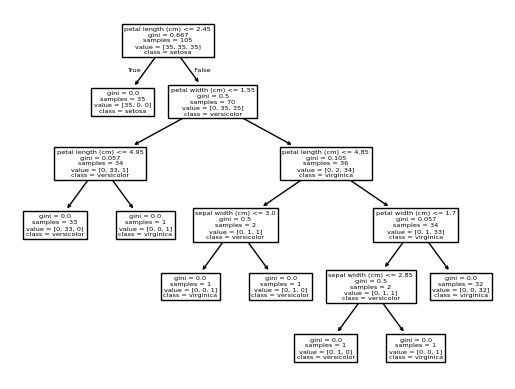

In [37]:
from sklearn.tree import plot_tree

plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names)

Visualizziamo ora la pipeline completa:
1. Caricamento del dataset
2. Split in training e test set
3. Creazione e addestramento del classificatore
4. Utilizzo e validazione del classificatore
5. Visualizzazione dell'albero

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.93      0.97        15
           2       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45

Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]


[Text(0.3181818181818182, 0.9166666666666666, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 105\nvalue = [35, 35, 35]\nclass = setosa'),
 Text(0.22727272727272727, 0.75, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]\nclass = setosa'),
 Text(0.2727272727272727, 0.8333333333333333, 'True  '),
 Text(0.4090909090909091, 0.75, 'petal width (cm) <= 1.55\ngini = 0.5\nsamples = 70\nvalue = [0, 35, 35]\nclass = versicolor'),
 Text(0.36363636363636365, 0.8333333333333333, '  False'),
 Text(0.18181818181818182, 0.5833333333333334, 'petal length (cm) <= 4.95\ngini = 0.057\nsamples = 34\nvalue = [0, 33, 1]\nclass = versicolor'),
 Text(0.09090909090909091, 0.4166666666666667, 'gini = 0.0\nsamples = 33\nvalue = [0, 33, 0]\nclass = versicolor'),
 Text(0.2727272727272727, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.6363636363636364, 0.5833333333333334, 'petal length (cm) <= 4.85\ngini = 0.105\nsamples = 36\nvalue = [0, 2, 34]\nclass = virginica'),

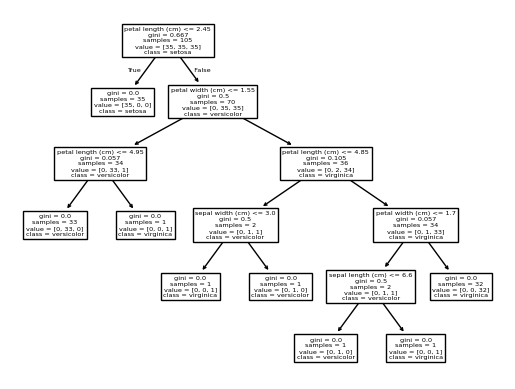

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report, confusion_matrix


# 1. Caricamento del dataset
iris = load_iris()
X, y = iris.data, iris.target

# 2. Split in training e test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Creazione e addestramento del classificatore
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

# 4. Utilizzo e validazione del classificatore
y_pred = tree.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names)


## Esercizio 2

Ripeti il workflow completo sul dataset **Wine** (load_wine), questa volta con una cross validation:
1. Carica il dataset
2. Utilizza un 5-fold cross validation
3. Addestra un DecisionTreeClassifier
4. Calcola le diverse metriche

### Soluzione 1

In [1]:
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Carica il dataset Wine
wine = load_wine()
X, y = wine.data, wine.target

# 2. Utilizza un 5-fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Addestra un DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state=42)

# Inizializza liste per raccogliere i risultati aggregati
all_y_test = []
all_y_pred = []

# Ciclo sui fold
for i, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    # Dividere i dati
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Addestrare e predire
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    
    # Raccogli i risultati aggregati
    all_y_test.extend(y_test) # .extend aggiunge gli elementi di y_test alla lista all_y_test
    all_y_pred.extend(y_pred) # .extend aggiunge gli elementi di y_pred alla lista all_y_pred


    # 4. Calcola le diverse metriche
    print(f"\n{'='*50}")
    print(f"FOLD {i+1}")
    print(f"{'='*50}")
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=wine.target_names))


print(f"\n{'='*50}")
print("RISULTATI AGGREGATI")
print(f"{'='*50}")

print("\nClassification Report complessivo:")
print(classification_report(all_y_test, all_y_pred, target_names=wine.target_names))



FOLD 1

Confusion Matrix:
[[11  1  0]
 [ 2 11  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

     class_0       0.85      0.92      0.88        12
     class_1       0.92      0.79      0.85        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.89        36
   macro avg       0.89      0.90      0.89        36
weighted avg       0.89      0.89      0.89        36


FOLD 2

Confusion Matrix:
[[12  0  0]
 [ 1 13  0]
 [ 0  2  8]]

Classification Report:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.87      0.93      0.90        14
     class_2       1.00      0.80      0.89        10

    accuracy                           0.92        36
   macro avg       0.93      0.91      0.92        36
weighted avg       0.92      0.92      0.92        36


FOLD 3

Confusion Matrix:
[[11  1  0]
 [ 0 12  2]
 [ 0  1  9]

### Soluzione 2

In [41]:
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np


# 1. Carica il dataset Wine
wine = load_wine()
X, y = wine.data, wine.target


# 2. Utilizza un 5-fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Addestra un DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state=42)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# cross_validate fa automaticamente tutto quello che nella prima soluzione facevamo a mano col ciclo for 
results = cross_validate(
    tree,
    X,
    y,
    cv=cv,
    scoring=scoring
)

# 4. Calcola le diverse metriche
for metric in scoring:
    print(f"{metric}: {np.mean(results['test_' + metric]):.3f}")
    
# Bonus, mostra anche i risultati per ogni fold
for metric in scoring:
    scores = results['test_' + metric]
    print(f"\n{metric}:")
    for i, score in enumerate(scores):
        print(f"  Fold {i+1}: {score:.3f}")
    print(f"  Media: {np.mean(scores):.3f}")
    print(f"  Std:   {np.std(scores):.3f}")

accuracy: 0.893
precision_macro: 0.904
recall_macro: 0.895
f1_macro: 0.896

accuracy:
  Fold 1: 0.889
  Fold 2: 0.917
  Fold 3: 0.889
  Fold 4: 0.829
  Fold 5: 0.943
  Media: 0.893
  Std:   0.038

precision_macro:
  Fold 1: 0.891
  Fold 2: 0.930
  Fold 3: 0.892
  Fold 4: 0.846
  Fold 5: 0.961
  Media: 0.904
  Std:   0.039

recall_macro:
  Fold 1: 0.901
  Fold 2: 0.910
  Fold 3: 0.891
  Fold 4: 0.832
  Fold 5: 0.939
  Media: 0.895
  Std:   0.035

f1_macro:
  Fold 1: 0.893
  Fold 2: 0.915
  Fold 3: 0.890
  Fold 4: 0.836
  Fold 5: 0.946
  Media: 0.896
  Std:   0.036


## cross_validate vs ciclo manuale

Come detto cross_validate automatizza il ciclo della prima soluzione.
Con sole 5 righe di codice abbiamo riassunto circa 25 righe di codice di soluzione 1.

Pro e contro:
cross_validate non restituisce direttamente le predizioni, ma ci da già i risultati aggregati.
Se dovesse servirci calcolare le confusion matrix o avere un accesso più diretto alle predizioni, è indicato utilizzare il ciclo